In [97]:
import numpy as np, awkward as ak, uproot, math
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

In [98]:
FILE = "/ceph/omunkombwe/fit__idea_o1_v03_60.root"
TREE = "events"

In [99]:
pt_bins = np.linspace(0.65, 5, 25)

In [100]:
# collectionIDs for fitted-track hit refs 
CID = {
    'DCH_DigiCollection': np.uint32(3486206992), 
}
COUNTABLE_CIDS = {CID['DCH_DigiCollection']}  

In [101]:
with uproot.open(FILE) as f:
    t = f[TREE]
    arr = t.arrays([
        # ---- Truth (kinematics + vertex) ----
        "MCParticles.momentum.x","MCParticles.momentum.y","MCParticles.momentum.z",
        "MCParticles.PDG","MCParticles.generatorStatus",
    
        # ---- Fitted tracks → flattened hit refs ----
        "CDCHTracks.trackerHits_begin", "Fitted_tracks_muon.trackerHits_begin", "Fitted_tracks_muon.trackerHits_end",
        "CDCHTracks.trackerHits_end",
        "_CDCHTracks_trackerHits.index", "_Fitted_tracks_muon_trackerHits.index", "_Fitted_tracks_muon_trackerHits.collectionID",
        "_CDCHTracks_trackerHits.collectionID",

        # ---- Sim links (digi ↔ sim ↔ MC) for ALL subdetectors ----
        "_DCH_DigiSimAssociationCollection_from.index",
        "_DCH_DigiSimAssociationCollection_to.index",
        "_DCHCollection_particle.index",
    ], how=dict)

In [102]:
mc_px, mc_py, mc_pz = arr["MCParticles.momentum.x"], arr["MCParticles.momentum.y"], arr["MCParticles.momentum.z"]
mc_pdg, mc_gen = arr["MCParticles.PDG"], arr["MCParticles.generatorStatus"]

In [103]:
T_hit_beg  = arr["Fitted_tracks_muon.trackerHits_begin"]
T_hit_end  = arr["Fitted_tracks_muon.trackerHits_end"]
T_hit_idx  = arr["_Fitted_tracks_muon_trackerHits.index"]
T_hit_cid  = arr["_Fitted_tracks_muon_trackerHits.collectionID"]

In [104]:
# ---- Links (digis ↔ simhits ↔ MC)
DCH_from = arr["_DCH_DigiSimAssociationCollection_from.index"]
DCH_to   = arr["_DCH_DigiSimAssociationCollection_to.index"]
DCH_sim2mc = arr["_DCHCollection_particle.index"]


In [105]:
# ---- Truth kinematics & selections ----
mc_pt = np.sqrt(mc_px**2 + mc_py**2)
is_mu = (abs(mc_pdg) == 13)
is_final = (mc_gen == 1)

In [106]:
# ==========================================================
def make_digi_to_mc_map(digi_from, digi_to_sim, sim_to_mc, valid_mask=None):
    out = []
    for evt, (frm, to, sim2mc_evt) in enumerate(zip(digi_from, digi_to_sim, sim_to_mc)):
        frm_evt = ak.to_numpy(frm)
        to_evt = ak.to_numpy(to)
        sim2mc_arr = ak.to_numpy(sim2mc_evt)
        valid_evt = None if valid_mask is None else ak.to_numpy(valid_mask[evt])

        acc = defaultdict(lambda: defaultdict(int))  # acc[d][mc] -> count
        for d, s in zip(frm_evt, to_evt):
            if d is None or s is None:
                continue
            if s < 0 or s >= len(sim2mc_arr):
                continue
            d_int = int(d)
            if valid_evt is not None:
                if d_int < 0 or d_int >= len(valid_evt) or not valid_evt[d_int]:
                    continue
            mcid = sim2mc_arr[s]
            if mcid is None or mcid < 0:
                continue
            acc[d_int][int(mcid)] += 1
        # choose max-count MC per digi
        mapping = {}
        for d, bucket in acc.items():
            # deterministic tie-break: highest count, then largest mcid
            best_mcid, best_cnt = None, -1
            for mcid, cnt in bucket.items():
                if (cnt > best_cnt) or (cnt == best_cnt and (best_mcid is None or mcid > best_mcid)):
                    best_mcid, best_cnt = mcid, cnt
            mapping[int(d)] = best_mcid
        out.append(mapping)
    return out


In [107]:
# Build majority maps for drift chamber only
dch_map = make_digi_to_mc_map(DCH_from, DCH_to, DCH_sim2mc) #valid_mask=DCH_residual_ok


In [108]:
# hit→MC for fitted-track hits -- maps to label each fitted-track hit by its MC id --
def hit_to_mc_for_event(evt, col_id, idx):
    if col_id == CID['DCH_DigiCollection']:
        return dch_map[evt].get(int(idx), None)
    return None


In [109]:
# SIM-HIT totals per MC for drift chamber only (denominator uses all DCH sim-hits)
# ==========================================================
def truth_simhits_all(evt):
    counts = Counter()
    for mcid in ak.to_numpy(DCH_sim2mc[evt]):
        if mcid is None or mcid < 0:
            continue
        counts[int(mcid)] += 1
    return counts


In [110]:
# ---Binning tallies--
den = np.zeros(len(pt_bins)-1)
num = np.zeros(len(pt_bins)-1)

In [111]:
# ---------------- Main events loop -----------------
n_events = len(mc_pt)
for evt in range(n_events):
    # truth preselection 
    mask_truth = (is_mu[evt]) & (is_final[evt]) 
    #& (from_ip[evt]) 
    if not ak.any(mask_truth):
        continue

    # SIM-HIT totals per MC (hit-eff denominator) and reconstructable set
    truth_hits_by_mc = truth_simhits_all(evt)

    truth_ids_evt = np.flatnonzero(ak.to_numpy(mask_truth))
    pts_evt = ak.to_numpy(mc_pt[evt])[ak.to_numpy(mask_truth)]

    recon_ids, recon_pts = [], [] # used to fill den via binning
    for tid, pt in zip(truth_ids_evt, pts_evt):
        if truth_hits_by_mc.get(int(tid), 0): # V>= nhit_min
            recon_ids.append(int(tid))
            recon_pts.append(float(pt))
    if not recon_ids:
        continue

    # For each track, build contribution counts via majority digi→MC mapping
    beg_evt, end_evt = T_hit_beg[evt], T_hit_end[evt]
    idx_flat, col_flat = T_hit_idx[evt], T_hit_cid[evt]

    candidates = []  # (truth_id, shared, purity, hit_eff)
    for b, e in zip(beg_evt, end_evt):
        if b is None or e is None or e <= b:
            continue
        ids  = idx_flat[b:e]
        cols = col_flat[b:e]

        total_track_hits = 0
        contrib = Counter()  # hits on this track coming from each MC

        for idx_val, col_val in zip(ids, cols):
            if idx_val is None or col_val is None:
                continue
            col_val = np.uint32(col_val)
            if col_val not in COUNTABLE_CIDS:
                continue
            total_track_hits += 1
            mcid = hit_to_mc_for_event(evt, col_val, int(idx_val))
            if mcid is None:
                continue
            contrib[mcid] += 1

        if total_track_hits == 0 or not contrib:
            continue

        best_mcid, shared = contrib.most_common(1)[0]
        purity = shared / float(total_track_hits)

        truth_total = float(truth_hits_by_mc.get(best_mcid, 0))  # SIM-HITS denominator
        hit_eff = (shared / truth_total) if truth_total > 0 else 0.0

        # ===== thresholds =====
        if (purity >= 0.50) and (hit_eff >= 0.50) and (shared): # V>= nhit_min
            candidates.append((best_mcid, shared, purity, hit_eff))



    # ====================================
    # one-to-one truth↔track: keep the candidate with largest 'shared'
    best_by_truth = {}
    for mcid, shared, pur, hef in candidates:
        if (mcid not in best_by_truth) or (shared > best_by_truth[mcid][0]):
            best_by_truth[mcid] = (shared, pur, hef)

    matched_truth_ids = set(best_by_truth.keys())

    # fill num/den by pT bins for reconstructable truths
    bins_idx = np.digitize(recon_pts, pt_bins) - 1
    for tid, b in zip(recon_ids, bins_idx):
        if 0 <= b < len(den):
            den[b] += 1
            if tid in matched_truth_ids:
                num[b] += 1
# ---------------- End of events loop -----------------



In [112]:
# Wald interval (~68%)
eff, err_wald = [], []
Z = 1
for k, n in zip(num, den):
    if n == 0:
        eff.append(np.nan); err_wald.append(np.nan); continue
    p_hat = k / n
    sigma = math.sqrt(max(p_hat*(1.0 - p_hat)/n, 0.0))
    eff.append(p_hat)
    err_wald.append(Z * sigma)


In [113]:

centers = 0.5*(pt_bins[:-1] + pt_bins[1:])
#xerr = np.diff(pt_bins)/2


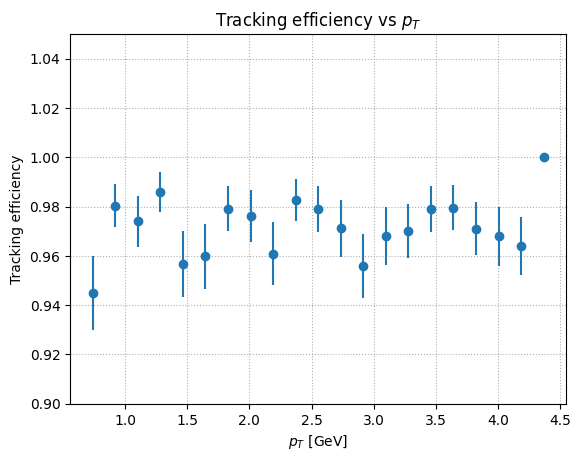

num (matched): [223.0, 250.0, 225.0, 210.0, 221.0, 215.0, 235.0, 206.0, 221.0, 226.0, 234.0, 203.0, 239.0, 212.0, 227.0, 234.0, 240.0, 235.0, 211.0, 241.0, 76.0, 0.0, 0.0, 0.0]
den (reconstructable): [236.0, 255.0, 231.0, 213.0, 231.0, 224.0, 240.0, 211.0, 230.0, 230.0, 239.0, 209.0, 250.0, 219.0, 234.0, 239.0, 245.0, 242.0, 218.0, 250.0, 76.0, 0.0, 0.0, 0.0]


In [114]:
plt.figure()
plt.errorbar(centers, eff, yerr=err_wald, fmt='o', linestyle='None')
plt.ylim(0.9, 1.05)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Tracking efficiency")
plt.grid(True, ls=":")
plt.title(r"Tracking efficiency vs $p_T$")
plt.savefig("eff_vs_pt_wald.png", dpi=300)
plt.show()

#print("Bins (GeV):", list(zip(pt_bins[:-1], pt_bins[1:])))
print("num (matched):", num.tolist())
print("den (reconstructable):", den.tolist())
